###**Importing the Dataset from Kaggle**

In [ ]:
import kagglehub

path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


###**Importing Necessary Libraries**

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 758.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 100.9 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout, GlobalAveragePooling2D
import matplotlib.pyplot as plt
import cv2

###**Loading the Train and Test Data**

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=path + '/train',
    labels='inferred',
    label_mode='int',
    batch_size=64,
    image_size=(256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=path + '/test',
    labels='inferred',
    label_mode='int',
    batch_size=64,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


###**Applying Pre-Processing** <br>
Normalizing the Pixel Values for better Convergence

In [ ]:
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

###**Building the Baseline Model** <br>
Starting with a protoype to see where we stand at first then will tweak and iterate accordingly. The initial prototype consists of 3 Convolution Layers each of them followed by Batch Normalization and a Max Pooling Layer. The Kernel is designed as 3x3 starting with 32 of them in the first layer then increasing them progressively. Towards the end of the network it connects to a fully connected layer converging to the output with Sigmoid

In [ ]:
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 2nd Convolutional Block
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 3rd Convolutional Block
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Flattening and Fully Connected Layers
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

# Output Layer for Binary Classification
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

Compiling the Model with Adam Optimizer and Training it for 10 Epochs

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 273ms/step - accuracy: 0.5694 - loss: 1.6875 - val_accuracy: 0.5178 - val_loss: 1.9425
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 182ms/step - accuracy: 0.6473 - loss: 0.6400 - val_accuracy: 0.6594 - val_loss: 0.6277
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step - accuracy: 0.7052 - loss: 0.5599 - val_accuracy: 0.6938 - val_loss: 0.5861
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 176ms/step - accuracy: 0.7405 - loss: 0.4960 - val_accuracy: 0.7336 - val_loss: 0.5036
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 179ms/step - accuracy: 0.7862 - loss: 0.4259 - val_accuracy: 0.7674 - val_loss: 0.5129
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 177ms/step - accuracy: 0.8138 - loss: 0.3804 - val_accuracy: 0.7814 - val_loss: 0.4676
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - accuracy: 0.8317 - loss: 0.3365 - val_accuracy: 0.7054 - val_loss: 0.8299
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 177ms/step - accuracy: 0.8482 - loss: 

There seems to be a bit of Overfitting, let's have a look at the Curves

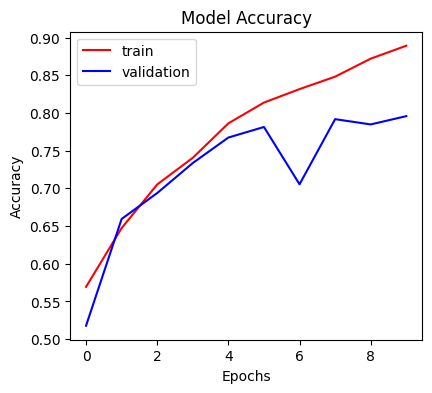

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

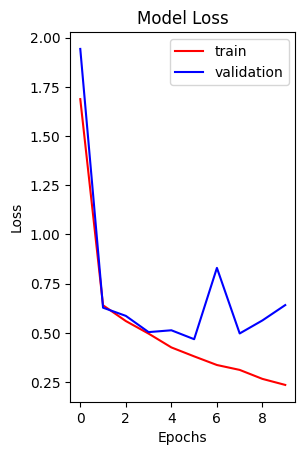

In [ ]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


The model provided decent results for a starting point and we can infer a lot of things from it. To begin with, the model slightly overfits the training data showing an 11% difference in accuracy compared to the validation set. The learning doesn't plateau so more epochs would help too. Apart from that it does seem like a strong baseline. Let's tweak few stuff and re-train.

###**Training V2** <br>
Adding an additional Convolution Block with 256 filters, this would help in reducing the parameters a bit also would capture more features. Also increasing the Dropout Layer ratio to minimize Overfitting. Everything else is pretty much the same

In [ ]:
model_v2 = Sequential()

# 1st Convolutional Block
model_v2.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model_v2.add(BatchNormalization())
model_v2.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 2nd Convolutional Block
model_v2.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model_v2.add(BatchNormalization())
model_v2.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 3rd Convolutional Block
model_v2.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model_v2.add(BatchNormalization())
model_v2.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

#4th Convolutional Block
model_v2.add(Conv2D(256, kernel_size=(3, 3), padding='valid', activation='relu'))
model_v2.add(BatchNormalization())
model_v2.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Flattening and Fully Connected Layers
model_v2.add(Flatten())

model_v2.add(Dense(128, activation='relu'))
model_v2.add(Dropout(0.3))

model_v2.add(Dense(64, activation='relu'))
model_v2.add(Dropout(0.2))

# Output Layer for Binary Classification
model_v2.add(Dense(1, activation='sigmoid'))

model_v2.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,821,313 (26.02 MB)

 Trainable params: 6,820,353 (26.02 MB)

 Non-trainable params: 960 (3.75 KB)

Keeping the compilation parameters same

In [ ]:
model_v2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_v2.fit(train_ds, epochs=25, validation_data=validation_ds)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 209ms/step - accuracy: 0.5480 - loss: 1.1801 - val_accuracy: 0.5504 - val_loss: 0.6960
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 196ms/step - accuracy: 0.5855 - loss: 0.6637 - val_accuracy: 0.6152 - val_loss: 0.6548
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 192ms/step - accuracy: 0.6198 - loss: 0.6283 - val_accuracy: 0.6814 - val_loss: 0.5908
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.6541 - loss: 0.5896 - val_accuracy: 0.5744 - val_loss: 0.7722
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 203ms/step - accuracy: 0.7001 - loss: 0.5304 - val_accuracy: 0.6008 - val_loss: 0.6138
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 196ms/step - accuracy: 0.7729 - loss: 0.4651 - val_accuracy: 0.8110 - val_loss: 0.4078
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 201ms/step - accuracy: 0.8083 - loss: 0.4108 - val_accuracy: 0.5862 - val_loss: 2.2212
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 193ms/step - accuracy: 0.8364 - loss: 0

Plotting the Curves

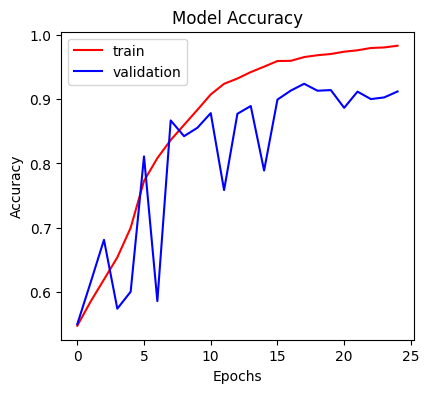

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

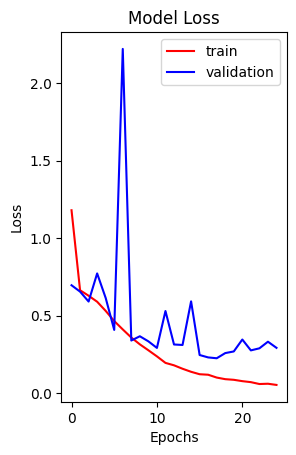

In [ ]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


This model reveals a lot of stuff, although there is still overfitting but the results have significantly improved from the previous model. There is more than 10% jump in accuracy from the previous model, the effect of overfitting is somewhat similar and the parameters have also been reduced reducing the model size almost to half. Let's tweak more.

###**Training V3** <br>
We could be increasing the Dropout ratio even more but doing 2 changes concurrently wont let us know from where the improvement came from so maybe save it for V4, using Global Average Pooling as the Flattening layer (Will reduce Parameters significantly) adding a Convolution Layer each in Block 3 and 4 to see if there are any more features it could potentially capture. Also reducing the Epochs to 20 as it can be seen it starts to plateau at/towards the 20th Epoch.

In [ ]:
model_v3 = Sequential()

# 1st Convolutional Block
model_v3.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model_v3.add(BatchNormalization())
model_v3.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 2nd Convolutional Block
model_v3.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model_v3.add(BatchNormalization())
model_v3.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 3rd Convolutional Block
model_v3.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model_v3.add(BatchNormalization())
model_v3.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model_v3.add(BatchNormalization())
model_v3.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

#4th Convolutional Block
model_v3.add(Conv2D(256, kernel_size=(3, 3), padding='valid', activation='relu'))
model_v3.add(BatchNormalization())
model_v3.add(Conv2D(256, kernel_size=(3, 3), padding='valid', activation='relu'))
model_v3.add(BatchNormalization())
model_v3.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Flattening and Fully Connected Layers with GAP
model_v3.add(GlobalAveragePooling2D())

model_v3.add(Dense(128, activation='relu'))
model_v3.add(Dropout(0.3))

model_v3.add(Dense(64, activation='relu'))
model_v3.add(Dropout(0.2))

# Output Layer for Binary Classification
model_v3.add(Dense(1, activation='sigmoid'))

model_v3.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 58, 58, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,170,753 (4.47 MB)

 Trainable params: 1,169,025 (4.46 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [ ]:
model_v3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_v3 = model_v3.fit(train_ds, epochs=20, validation_data=validation_ds)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 127s 325ms/step - accuracy: 0.6628 - loss: 0.6132 - val_accuracy: 0.5008 - val_loss: 1.2120
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 237ms/step - accuracy: 0.7505 - loss: 0.5188 - val_accuracy: 0.5270 - val_loss: 0.8098
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 239ms/step - accuracy: 0.8083 - loss: 0.4240 - val_accuracy: 0.7816 - val_loss: 0.4805
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 240ms/step - accuracy: 0.8732 - loss: 0.3046 - val_accuracy: 0.7300 - val_loss: 0.5333
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 245ms/step - accuracy: 0.9039 - loss: 0.2304 - val_accuracy: 0.8424 - val_loss: 0.3374
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 244ms/step - accuracy: 0.9262 - loss: 0.1855 - val_accuracy: 0.8968 - val_loss: 0.2531
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 239ms/step - accuracy: 0.9366 - loss: 0.1550 - val_accuracy: 0.8406 - val_loss: 0.4508
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.9488 - loss: 

###**Training V4** <br>

There is still considerable amount of Overfitting, increasing the Dropout ratio from 0.3/0.2 to 0.5/0.3 for better Validation Results. Also turning on the padding to extract more information from the Images.

In [ ]:
model_v4 = Sequential()

# 1st Convolutional Block
model_v4.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(256, 256, 3)))
model_v4.add(BatchNormalization())
model_v4.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))

# 2nd Convolutional Block
model_v4.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model_v4.add(BatchNormalization())
model_v4.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))

# 3rd Convolutional Block
model_v4.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model_v4.add(BatchNormalization())
model_v4.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model_v4.add(BatchNormalization())
model_v4.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))

# 4th Convolutional Block
model_v4.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model_v4.add(BatchNormalization())
model_v4.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model_v4.add(BatchNormalization())
model_v4.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))

# Flattening and Fully Connected Layers with GAP
model_v4.add(GlobalAveragePooling2D())

model_v4.add(Dense(128, activation='relu'))
model_v4.add(Dropout(0.5))

model_v4.add(Dense(64, activation='relu'))
model_v4.add(Dropout(0.3))

# Output Layer for Binary Classification
model_v4.add(Dense(1, activation='sigmoid'))

model_v4.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,170,753 (4.47 MB)

 Trainable params: 1,169,025 (4.46 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [ ]:
model_v4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_v4 = model_v4.fit(train_ds, epochs=20, validation_data=validation_ds)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 341ms/step - accuracy: 0.6130 - loss: 0.6586 - val_accuracy: 0.5018 - val_loss: 0.9001
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 262ms/step - accuracy: 0.6923 - loss: 0.5873 - val_accuracy: 0.6620 - val_loss: 0.6107
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.7565 - loss: 0.5131 - val_accuracy: 0.5978 - val_loss: 0.7151
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 257ms/step - accuracy: 0.8070 - loss: 0.4362 - val_accuracy: 0.7328 - val_loss: 0.5525
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 259ms/step - accuracy: 0.8616 - loss: 0.3359 - val_accuracy: 0.6950 - val_loss: 0.5610
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 260ms/step - accuracy: 0.8898 - loss: 0.2726 - val_accuracy: 0.6360 - val_loss: 0.8078
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.9143 - loss: 0.2135 - val_accuracy: 0.6976 - val_loss: 0.9430
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 258ms/step - accuracy: 0.9333 - loss: 

###**Training_V5** <br>

Reverting the Dropout to determine what caused the improvement was it the Dropout or the Padding. Also letting it run for few more Epochs just for safety.

In [ ]:
model_v5 = Sequential()

# 1st Convolutional Block
model_v5.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(256, 256, 3)))
model_v5.add(BatchNormalization())
model_v5.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))

# 2nd Convolutional Block
model_v5.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model_v5.add(BatchNormalization())
model_v5.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))

# 3rd Convolutional Block
model_v5.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model_v5.add(BatchNormalization())
model_v5.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model_v5.add(BatchNormalization())
model_v5.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))

# 4th Convolutional Block
model_v5.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model_v5.add(BatchNormalization())
model_v5.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model_v5.add(BatchNormalization())
model_v5.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))

# Flattening and Fully Connected Layers with GAP
model_v5.add(GlobalAveragePooling2D())

model_v5.add(Dense(128, activation='relu'))
model_v5.add(Dropout(0.3))

model_v5.add(Dense(64, activation='relu'))
model_v5.add(Dropout(0.2))

# Output Layer for Binary Classification
model_v5.add(Dense(1, activation='sigmoid'))

model_v5.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,170,753 (4.47 MB)

 Trainable params: 1,169,025 (4.46 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [ ]:
model_v5.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_v5 = model_v5.fit(train_ds, epochs=25, validation_data=validation_ds)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 283ms/step - accuracy: 0.6172 - loss: 0.6474 - val_accuracy: 0.5000 - val_loss: 0.9532
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.6938 - loss: 0.5788 - val_accuracy: 0.5168 - val_loss: 1.5778
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.7416 - loss: 0.5222 - val_accuracy: 0.5756 - val_loss: 0.7545
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.7925 - loss: 0.4566 - val_accuracy: 0.7584 - val_loss: 0.5072
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.8324 - loss: 0.3861 - val_accuracy: 0.7798 - val_loss: 0.5122
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.8744 - loss: 0.3018 - val_accuracy: 0.8264 - val_loss: 0.3739
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 259ms/step - accuracy: 0.9058 - loss: 0.2363 - val_accuracy: 0.8516 - val_loss: 0.3319
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.9238 - loss: 

### **Conclusion** <br>

This project explored CNN architecture through a series of controlled experiments, starting with the original LeNet and progressively improving it. The final model achieved 94.10% validation accuracy, compared to 79.58% with the original architecture. The experiments showed how convolutional depth, Global Average Pooling, and dropout can influence model performance and generalization. The main takeaway was that thoughtful architectural changes and experimentation matter more than simply increasing model complexity.


### **Saving the Best Model**

In [ ]:
from tensorflow.keras.models import load_model
from google.colab import files

# Save model_v4 before downloading
model_v4.save("cats_dogs_v4.keras")
files.download("cats_dogs_v4.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history_v4.history)
history_df.to_csv('history_v4.csv', index=False)
files.download('history_v4.csv')